In [1]:
# illustrative example of use VeraRubin 

## Injection procedure example 

> Version: 1.0
> 
> Container Size: Large
>
> Description: In this notebook, we present an illustrative example of the use of the VeraRubin package, to inject a stamp. In particular, we work with a local repository.

In [2]:
# Complementary info
! echo $IMAGE_DESCRIPTION
! eups list -s | grep lsst_distrib

!python --version

Release r29.2.0 (RSP Build 2648)
lsst_distrib          gc675d380bf+f75de59d28 	current v29_2_0 v29_2_0_rc1 setup
Python 3.12.11


In [3]:
%load_ext autoreload
%autoreload 2

In [7]:
# Loading modules
import numpy as np
import VeraRubin as vr
#import astropy.units as u
import matplotlib.pyplot as plt

#from astropy.io import fits
from lsst.daf.butler import Butler

In [8]:
LOCAL_REPO = "./local_butler" 
lbutler = Butler(LOCAL_REPO, collections='local_main_chain') 

In [6]:
# Dataset types
!butler query-dataset-types --verbose $LOCAL_REPO

     name                                     dimensions                                 storage class 
------------- ------------------------------------------------------------------------- ---------------
deep_coadd    ['band', 'skymap', 'tract', 'patch']                                      ExposureF      
skyMap        ['skymap']                                                                SkyMap         
visit_image   ['band', 'instrument', 'day_obs', 'detector', 'physical_filter', 'visit'] ExposureF      
visit_summary ['band', 'instrument', 'day_obs', 'physical_filter', 'visit']             ExposureCatalog


In [7]:
!butler query-collections --chains 'TREE' $LOCAL_REPO

                            Name                              Type 
----------------------------------------------------------- -------
LSSTComCam/runs/DRP/DP1/DM-51335                            RUN    
LSSTComCam/runs/DRP/DP1/DM-53601                            RUN    
LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z   RUN    
direct_injected_run                                         RUN    
local_main_chain                                            CHAINED
  skymaps                                                   RUN    
  LSSTComCam/runs/DRP/DP1/DM-51335                          RUN    
  LSSTComCam/runs/DRP/DP1/DM-53601                          RUN    
  LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z RUN    
local_with_injection                                        CHAINED
  skymaps                                                   RUN    
  LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z RUN    
  direct_injected_run                           

## Injection

In [22]:
# Defining the sky coordinates and the selected band

ra_deg, dec_deg = (53.2, -27.8)  # RA, Dec
loc_data = (ra_deg, dec_deg)
band = 'u'

# Opening the FITS file
stamp_paths = ['stamp/PGC_038749_I_g_bbl2011_original.fits']

# Defining the properties of the stamp
mags = [14.8]  # Magnitude used to inject the stamp

# Sky position of the injection
ra_list, dec_list = [ra_deg], [dec_deg]

In [23]:
injected_exposure = vr.main_inject_stamp(
        REPO=LOCAL_REPO,
        collections='local_main_chain',
        loc=loc_data,
        band=band,
        stamp_paths=stamp_paths,
        mags=mags,
        ra_list=ra_list,
        dec_list=dec_list,
        sky_coordinates=True,
        use_patch_area=False,
        detectors=None,
        timespan=None,
        visit_ids= None, # [2024113000172], 
        num_select=None, #3, # 
        min_sep=0.0005,
        separation_spherical=True,
        keep_size=False,
        interp_order=3,
        update_wcs=False,
        info_save_path='local_butler/injected_information',
        rot_name_save="test/stamp_rotated",
        remove_rotated_stamps= True,
        info=True)

[INFO] Loading the butler...
[INFO] Injection on sky coordinates: RA=53.2, Dec=-27.8
[INFO] Found 8 visits for band=u
END: Collect visit exposures and getWcs info
Execution time: 14.023 seconds
[INFO] Using 8 visits after sorting and selection.
[INFO] Computed 8 rotation angles.


[INFO] Injection complete.


## Some plots

In [24]:
# Info
# Loading info
info_txt_path = 'local_butler/injected_information.txt'
with open(info_txt_path, "r") as f:
    info = json.load(f)

visit_name = info['Parameters']['visit_name']
points = info['Parameters']['points']
visits = info['data_Id']

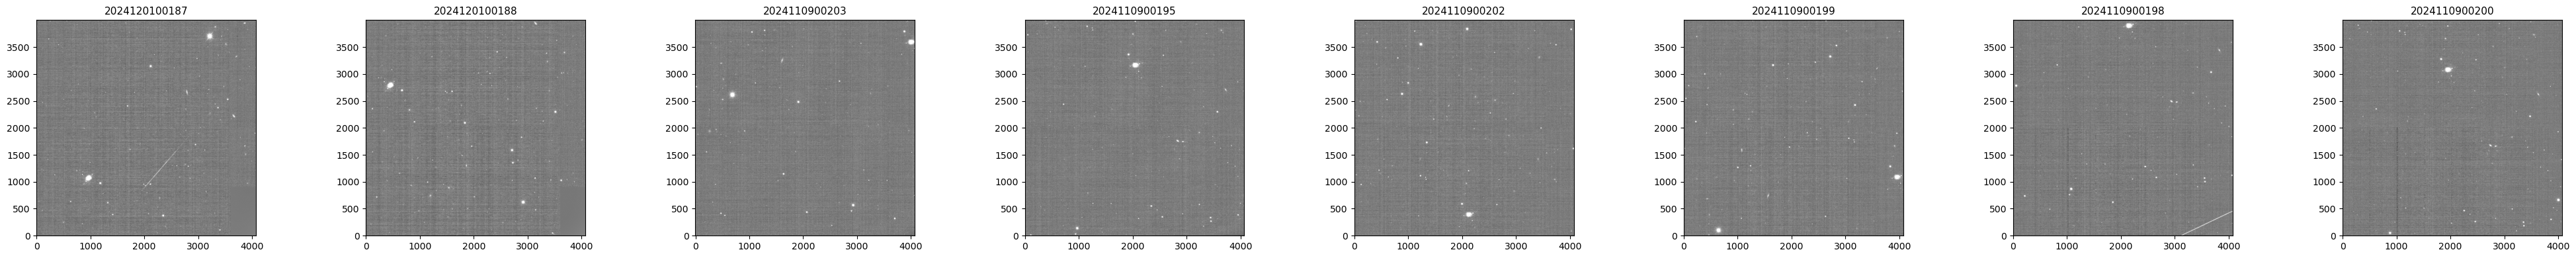

In [25]:
# Visualizing the result 
titles_id = [visits[str(i)]['dataId']['visit'] for i in range(len(injected_exposure))]
vr.plot_exposures_full(injected_exposure,
                       exposures_scale='percentile', # 'zscale_asinh',
                       coadd_exp_scale='percentile', # 'percentile' zscale_asinh
                       titles=titles_id,
                       show_second_row=False,
                       save_path=None)

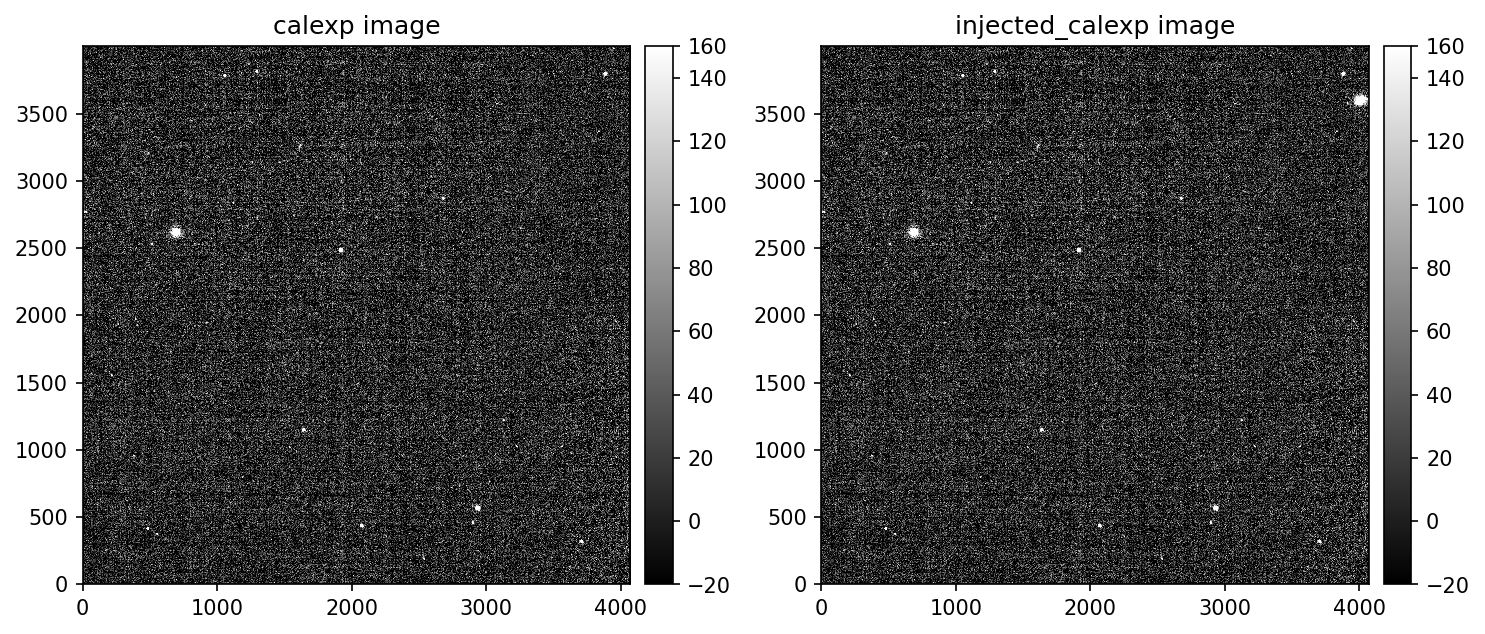

In [26]:
import lsst.afw.display as afwDisplay
afwDisplay.setDefaultBackend("matplotlib")

num = 2
visit_img = lbutler.get('visit_image', dataId=visits[str(num)]['dataId'])
plot_injected_img = injected_exposure[num].clone()

fig, ax = plt.subplots(1, 2, figsize=(10, 6), dpi=150)

plt.sca(ax[0])
display0 = afwDisplay.Display(frame=fig)
# display0.scale('linear', 'zscale')
display0.scale('linear', min=-20, max=150)
display0.mtv(visit_img.image)
plt.title('calexp image')

plt.sca(ax[1])
display1 = afwDisplay.Display(frame=fig)
# display1.scale('linear', 'zscale')
display1.scale('linear', min=-20, max=150)
display1.mtv(plot_injected_img.image)
# To zoom on the PGC 038749 stamp:
# display1.mtv(plot_injected_img.image[1700:2200, 1950:2450])
plt.title('injected_calexp image')

plt.tight_layout()
plt.show()

## Sending to the butler

The idea is make a new RUN where we save the modified visits and include it in a new chain with Skymap and the visit_summary

In [14]:
# identifying the RUN name of visit_summary
!butler query-datasets $LOCAL_REPO visit_summary \
  --collections local_main_chain \
  --limit 5


     type                                run                                             id                  instrument     visit     band day_obs  physical_filter
------------- --------------------------------------------------------- ------------------------------------ ---------- ------------- ---- -------- ---------------
visit_summary LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z 40d88711-8844-437e-a178-9fd81efb16d5 LSSTComCam 2024110900195    u 20241109            u_02
visit_summary LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z febf0396-9600-4ea0-ac83-2d7a9bd62e49 LSSTComCam 2024110900198    u 20241109            u_02
visit_summary LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z 89fbcba3-ec7b-40c7-b6b9-217af5cab113 LSSTComCam 2024110900199    u 20241109            u_02
visit_summary LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z fe73e7d3-2d66-424a-b2df-cd2cbc2c9ba5 LSSTComCam 2024110900200    u 20241109            u_02
visit_summary L

In [48]:
# Adding the new RUN/CHAIN
# IMPORTANT: if the RUN exists, we jump this step
members = ['skymaps',
           'LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z'  # visit_summary
          ]

vr.ensure_chained_collection(local_repo=LOCAL_REPO, 
                             run_name="direct_injected_run",
                             chain_name="local_with_injection",
                             members=members)

True

In [51]:
# Collections
!butler query-collections --chains 'TREE' $LOCAL_REPO

                            Name                              Type 
----------------------------------------------------------- -------
LSSTComCam/runs/DRP/DP1/DM-51335                            RUN    
LSSTComCam/runs/DRP/DP1/DM-53601                            RUN    
LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z   RUN    
direct_injected_run                                         RUN    
local_main_chain                                            CHAINED
  skymaps                                                   RUN    
  LSSTComCam/runs/DRP/DP1/DM-51335                          RUN    
  LSSTComCam/runs/DRP/DP1/DM-53601                          RUN    
  LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z RUN    
local_with_injection                                        CHAINED
  direct_injected_run                                       RUN    
  skymaps                                                   RUN    
  LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250

In [27]:
visits_data = [visits[str(i)]['dataId'] for i in range(len(visits))]

info = vr.save_visit_images(local_repo=LOCAL_REPO,
                         collections="local_with_injection",
                         run_name="direct_injected_run",
                         injected_exposures=injected_exposure,
                         dataset_type = "visit_image",
                         visits=visits_data,
                        )

[SKIP] visit 2024120100187 already exists.
[SKIP] visit 2024120100188 already exists.
[SKIP] visit 2024110900203 already exists.
[SKIP] visit 2024110900195 already exists.
[SKIP] visit 2024110900202 already exists.
[SKIP] visit 2024110900199 already exists.
[SKIP] visit 2024110900198 already exists.
[SKIP] visit 2024110900200 already exists.


In [28]:
# check
!butler query-dataset-types $LOCAL_REPO --collections local_with_injection

             name             
------------------------------
assembleDeepCoadd_config      
assembleDeepCoadd_log         
assembleDeepCoadd_metadata    
compare_warp_artifact_mask    
deep_coadd_input_map          
deep_coadd_n_image            
deep_coadd_predetection       
deep_coadd_visit_selection    
direct_warp                   
makeDirectWarp_config         
makeDirectWarp_log            
makeDirectWarp_metadata       
makePsfMatchedWarp_config     
makePsfMatchedWarp_log        
makePsfMatchedWarp_metadata   
packages                      
psf_matched_warp              
selectDeepCoaddVisits_config  
selectDeepCoaddVisits_log     
selectDeepCoaddVisits_metadata
skyMap                        
visit_image                   
visit_summary                 


In [29]:
# Validating
!butler query-datasets $LOCAL_REPO visit_image \
  --collections local_with_injection \
  --limit 5


    type            run                          id                  instrument detector     visit     band day_obs  physical_filter
----------- ------------------- ------------------------------------ ---------- -------- ------------- ---- -------- ---------------
visit_image direct_injected_run 108c0198-b654-4696-963b-cc8c07373089 LSSTComCam        2 2024110900195    u 20241109            u_02
visit_image direct_injected_run 2f7b7e0f-9b16-41ca-9b87-0952b88ae7ad LSSTComCam        8 2024110900202    u 20241109            u_02
visit_image direct_injected_run 7068a080-4714-4845-964e-6e945727f70d LSSTComCam        2 2024110900203    u 20241109            u_02
visit_image direct_injected_run f80794ab-4ad2-410f-a169-713a3808662b LSSTComCam        3 2024120100187    u 20241201            u_02
visit_image direct_injected_run 724bf240-8938-4348-8339-69c6880e5a5c LSSTComCam        3 2024120100188    u 20241201            u_02



### Save Info

In [30]:
info

{'saved': [],
 'skipped': [2024120100187,
  2024120100188,
  2024110900203,
  2024110900195,
  2024110900202,
  2024110900199,
  2024110900198,
  2024110900200]}